<div class="alert alert-block alert-info">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Hola Jorge soy Santiago y hoy reviso tu proyecto. Guia rapida de colores:

Por favor no muevas, edites ni elimines mis comentarios. Empecemos! 🚀
</div>
<div class="alert alert-block alert-success">Verde: algo esta bien hecho.</div>
<div class="alert alert-block alert-warning">Amarillo: tip o recomendacion, no bloquea la aprobacion.</div>
<div class="alert alert-block alert-danger">Rojo: necesita correccion antes de aprobar.</div>


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Encontre 4 problemas que si necesitan correccion antes de aprobar, tres de ellos bastante importantes:

- **Filtro no solicitado que descarta el 67% de los usuarios (celda 4.2):** `user_profile_2024 = user_profile[user_profile['reg_date'].dt.year == 2024]` reduce el dataset de 4000 a solo 1330 usuarios. Las instrucciones dicen que "trabajaremos con informacion registrada hasta el año 2024" - eso significa que el periodo de analisis llega hasta 2024, no que solo se analicen los usuarios que se registraron exactamente en 2024. Esto afecta toda la segmentacion (Paso 6) y el insight ejecutivo, que terminan analizando solo una cuarta parte de la base real de clientes.
- **La correccion de `reg_date` no funciono:** el codigo compara contra la fecha actual del sistema (`datetime.today()`) en vez de un limite fijo (2024). Lo confirme con tu propio output: despues de "corregir", `isna().sum()` da 0 y el maximo sigue siendo `2026-05-10` - el registro de 2026 nunca se marco como nulo.
- **El calculo de IQR usa el cuantil equivocado:** `Q1 = users_agg[col].quantile(.025)` deberia ser `.25` (percentil 25), no `.025` (percentil 2.5). Esto distorsiona todos los limites superior/inferior calculados despues.
- **Diagnostico de `type` incorrecto:** dice que las categorias son "Texto" y "llamadas", pero tu propio output de `.unique()` muestra `'call'` y `'text'` (en ingles, minusculas).

Tambien note dos errores de conteo en la seccion 2.2 (dice "40 mil datos" para columnas de `users`, que en realidad tiene 4000 filas, no 40,000 - esa cifra es la de `usage`), y el placeholder de GitHub sin reemplazar.

Con esos ajustes, el proyecto queda listo para aprobar.

</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (Iteracion 2)</b> <a class="tocSkip"></a>

Hola de nuevo, Jorge! Revise los 6 puntos de la Iteracion 1, uno por uno, verificando el output real:

1. **Filtro no solicitado (`user_profile_2024`) que descartaba el 67% de los usuarios:** CORREGIDO. Ya no existe ninguna referencia a ese filtro en el codigo actual - confirmado con una busqueda en todo el archivo.
2. **`reg_date` sin corregir (comparaba contra la fecha del sistema):** CORREGIDO. Ahora usa un limite fijo (`2024-12-31`), y el output confirma: 40 registros marcados como NA, ultima fecha valida `2024-12-31`.
3. **IQR con el cuantil equivocado (`.025` en vez de `.25`):** CORREGIDO.
4. **Diagnostico de `type` incorrecto ("Texto"/"llamadas"):** CORREGIDO - ahora dice correctamente "call" y "text".
5. **Errores de conteo (40 mil en vez de 4 mil para columnas de `users`):** CORREGIDO, e incluso agregaste la mencion del sentinel `-999` que faltaba en esa misma celda.
6. **GitHub - placeholder sin reemplazar:** sigue pendiente - la celda quedo vacia. Lo dejo como advertencia abajo y bloquea la aprobacion.

**Veredicto: No aprobado.** Resolviste los 5 puntos tecnicos, incluyendo el mas importante (el filtro que descartaba el 67% de los usuarios). Solo falta lo de github y quedas aprobado
</div>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos

plans = pd.read_csv("/app/plans.csv")
users = pd.read_csv("/app/users_latam.csv")
usage = pd.read_csv("/app/usage.csv")

In [3]:
# mostrar las primeras 5 filas de plans

plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users

users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage

usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()

usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

`.info()` correcto para los tres datasets.
</div>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print(users.isna().sum()) # Cantidad de valores nulos

print(users.isna().mean().sort_values(ascending=False)) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [11]:
# cantidad de nulos para usage

print(usage.isna().sum())
print(usage.isna().mean().sort_values(ascending=False)) 

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen calculo de nulos para `users` y `usage` por separado.
</div>

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint: 
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?


- del archivo users las columnas:
- churn_date tiene 88.350 %
- city tiene 11.725%

- Del archivo usage las columnas:
- duration tiene 55.190 %
-length tiene 44.740 %
-date tiene00.125 %

- Indica qué harías: ¿imputar, eliminar, ignorar?

- La columna duration tiene 55.190 %, por lo que se debe eliminar
- La columna -length tiene 44.740 %, pero se deja porque es la fecha de abandono del servicio

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users

users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene 4 mil filas
- La columna `age` tambien tiene los 4 mil filas y un sentinel de -999

<div class="alert alert-block alert-success">
<b>Comentario del revisor (Iteracion 2)</b> <a class="tocSkip"></a>

Corregido - ahora dice correctamente "4 mil filas", y ademas agregaste la mencion del sentinel `-999` que antes faltaba en esta celda.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Esta descripcion tiene un error de conteo: dice que `user_id` y `age` "tienen 40 mil datos", pero `users` tiene 4,000 filas, no 40,000 (esa cifra corresponde a `usage`, que revisas en la siguiente celda). Ademas, esta celda no menciona el sentinel `-999` en `age` (aunque si lo mencionas correctamente mas adelante, en el comentario de la celda 26).
</div>

In [13]:
# explorar columnas numéricas de usage

usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`siguen manteniendo los 40 mil filas.
- Las columnas 'duration' y 'length' tienen mucho menos datos

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Correcto aqui - 40,000 filas es el numero real de `usage`.
</div>

In [14]:

# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']]

# ver valores únicos
print(users['city'].unique())
print(users['plan'].unique())

# contar frecuencia de cada categoría
print(users['city'].value_counts())
print(users['plan'].value_counts())

# inspeccionar tipos de datos
print(columnas_user.dtypes)



['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64
city    object
plan    object
dtype: object


- La columna `city` tiene datos clasificados como '?'
- La columna `plan` contiene los 4 mil filas

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Mismo error de conteo: dice que `plan` "contiene los 40 mil datos", pero `plan` es una columna de `users` (4,000 filas), no de `usage`.
</div>

In [15]:
# explorar columna categórica de usage

# valores únicos
print(usage['type'].unique())

# conteo de cada categoría
print(usage['type'].value_counts())

# tipo de dato de la columna
print(usage['type'].dtypes)

['call' 'text']
text    22092
call    17908
Name: type, dtype: int64
object


- La columna `type` tiene dos opciones, "call" y "text"


<div class="alert alert-block alert-success">
<b>Comentario del revisor (Iteracion 2)</b> <a class="tocSkip"></a>

Corregido - ahora dice correctamente "call" y "text", coincidiendo con tu propio output de `.unique()`.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Esta descripcion no coincide con tu propio output de `.unique()`: los valores reales son `'call'` y `'text'` (en ingles, minusculas), no "Texto" y "llamadas". Por favor corrige el texto para que sea consistente con lo que realmente imprimiste.
</div>


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?  
- users → age: aparece el sentinel -999. Se reemplaza por la mediana (47 años).
- users → city: aparece el valor "?". Se reemplaza por NaN.
- usage → duration y length: valores extremos (hasta 120 min y 1490 caracteres). Son heavy users reales, se mantienen.
- users → reg_date: aparecen fechas futuras (2026). Se marcan como nulas.


In [52]:
# 🔧 Tip de mejora: encapsular exploración repetida en una función reutilizable

def valores_invalidos(df, columnas): 
    resultados = {}
    for col in columnas:
        # ejemplo: contar valores nulos y únicos
        resultados[col] = {
            "nulos": df[col].isna().sum(), 
            "unicos": df[col].unique() 
        } 
    return resultados

# Uso:
diagnostico = valores_invalidos(users, ["age", "city", "reg_date"])
print(diagnostico)

{'age': {'nulos': 0, 'unicos': array([38., 53., 57., 69., 63., 61., 39., 70., 76., 47., 67., 60., 48.,
       78., 77., 25., 51., 74., 64., 26., 68., 37., 42., 36., 22., 28.,
       32., 40., 44., 49., 43., 79., 59., 46., 56., 58., 50., 54., 33.,
       24., 29., 45., 66., 30., 35., 65., 18., 55., 19., 23., 41., 27.,
       34., 72., 75., 31., 71., 52., 20., 73., 21., 62.])}, 'city': {'nulos': 565, 'unicos': array(['Medellín', nan, 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali'],
      dtype=object)}, 'reg_date': {'nulos': 40, 'unicos': <DatetimeArray>
[          '2022-01-01 00:00:00+00:00', '2022-01-01 06:34:17.914478619+00:00',
 '2022-01-01 13:08:35.828957239+00:00', '2022-01-01 19:42:53.743435858+00:00',
 '2022-01-02 02:17:11.657914478+00:00', '2022-01-02 08:51:29.572393098+00:00',
 '2022-01-02 15:25:47.486871717+00:00', '2022-01-02 22:00:05.401350337+00:00',
 '2022-01-03 04:34:23.315828957+00:00', '2022-01-03 11:08:41.230307576+00:00',
 ...
 '2024-12-28 12:51:18.769692432+00:00', '2024-12-

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Tip para tu proximo proyecto: la rubrica tambien sugiere encapsular esta exploracion repetida en una funcion reutilizable, por ejemplo `def valores_invalidos(df, columnas): ...`. No bloquea esta entrega.
</div>

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce', utc=True)


In [18]:
print(users['reg_date'].head())
print(users['reg_date'].dtypes)


0             2022-01-01 00:00:00+00:00
1   2022-01-01 06:34:17.914478619+00:00
2   2022-01-01 13:08:35.828957239+00:00
3   2022-01-01 19:42:53.743435858+00:00
4   2022-01-02 02:17:11.657914478+00:00
Name: reg_date, dtype: datetime64[ns, UTC]
datetime64[ns, UTC]


In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce', utc=True)

In [20]:
print(usage['date'].head())
print(usage['date'].dtypes)


0             2024-01-01 00:00:00+00:00
1   2024-01-01 00:06:30.969774244+00:00
2   2024-01-01 00:13:01.939548488+00:00
3   2024-01-01 00:19:32.909322733+00:00
4   2024-01-01 00:26:03.879096977+00:00
Name: date, dtype: datetime64[ns, UTC]
datetime64[ns, UTC]


In [21]:
# Revisar los años presentes en `reg_date` de users

# extraer el año de reg_date
users['año_presente'] = users['reg_date'].dt.year

# ver años únicos
print(users['año_presente'].unique())

# contar cuántos registros hay por año
print(users['año_presente'].value_counts())

# inspeccionar ordenados
print(users['año_presente'].value_counts().sort_index())


[2022 2026 2023 2024]
2024    1330
2023    1316
2022    1314
2026      40
Name: año_presente, dtype: int64
2022    1314
2023    1316
2024    1330
2026      40
Name: año_presente, dtype: int64


En `reg_date`, Aparecen fechas futuras (2026), se marcan como nulas

In [22]:
# Revisar los años presentes en `date` de usage

# extraer el año de reg_date
usage['año_presente'] = usage['date'].dt.year

# ver años únicos
print(usage['año_presente'].unique())

# contar cuántos registros hay por año
print(usage['año_presente'].value_counts())

# inspeccionar ordenados
print(usage['año_presente'].value_counts().sort_index())

[2024.   nan]
2024.0    39950
Name: año_presente, dtype: int64
2024.0    39950
Name: año_presente, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- users → reg_date: se detectaron registros con años futuros (2026), lo cual es imposible porque el análisis está limitado hasta 2024.
- usage → date: todos los registros corresponden al año 2024, salvo un pequeño porcentaje de nulos (0.12%).

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Excluir el sentinel antes de calcular la mediana
age_mediana = users.loc[users['age'] != -999, 'age'].median()

# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Nota tecnica: `age_mediana` se calcula sin excluir el `-999` primero. En este caso no distorsiona el resultado (el percentil 25 ya es 32, positivo), pero una practica mas defensiva es excluir el sentinel antes: `users.loc[users['age'] != -999, 'age'].median()`.
</div>

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].isna().sum())  #cuantos NaN hay ahora
print(users['city'].unique())    #cuantas ciudades hay


565
['Medellín' nan 'CDMX' 'Bogotá' 'GDL' 'MTY' 'Cali']


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

`city` con `NaN` real (usando `np.nan`, equivalente a `pd.NA` para este proposito) - correcto.
</div>

In [25]:
from datetime import datetime

# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce', utc=True)

# usar un límite fijo en UTC (31 de diciembre de 2024)
limite = pd.Timestamp("2024-12-31", tz='UTC')

# Reemplazar fechas futuras con NA
users.loc[users['reg_date'] > limite, 'reg_date'] = pd.NaT

# Verificar cambios
print("total de NA:", users['reg_date'].isna().sum())   # cuántos quedaron como NA
print("última fecha válida", users['reg_date'].max())          # última fecha válida
print("primera fecha válida", users['reg_date'].min())          # primera fecha válida



total de NA: 40
última fecha válida 2024-12-31 00:00:00+00:00
primera fecha válida 2022-01-01 00:00:00+00:00


<div class="alert alert-block alert-success">
<b>Comentario del revisor (Iteracion 2)</b> <a class="tocSkip"></a>

Corregido - ahora usa un limite fijo (`2024-12-31`) en vez de la fecha del sistema. Verifique el output real: 40 registros marcados como NA, y la ultima fecha valida es `2024-12-31` (ya no aparece `2026-05-10`). Esto resuelve el problema de raiz.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Este codigo no logra lo que pide la instruccion. En vez de usar un limite fijo (el periodo del proyecto es hasta 2024), comparas contra `datetime.today()` (la fecha real del sistema al momento de ejecutar el notebook). Verifique el output de esta misma celda: `isna().sum()` da **0** y el maximo de `reg_date` sigue siendo **2026-05-10** - el registro de 2026 nunca se marco como nulo, porque para el sistema esa fecha ya no es "futura" respecto a hoy.

Corrige usando el limite del proyecto, no la fecha actual:

```python
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
```
</div>

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
print(usage.columns)

Index(['id', 'user_id', 'type', 'date', 'duration', 'length', 'año_presente'], dtype='object')


In [27]:
# Verificación MAR en usage (Missing At Random) para duration

print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))


type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [28]:
# Verificación MAR en usage (Missing At Random) para length

print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

type
call    0.99933
text    0.00000
Name: length, dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Verificacion MAR correcta y bien cuantificada.
</div>

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

`duration`: los nulos aparecen casi exclusivamente en registros de tipo text (≈99.9%).

`length`: los nulos aparecen casi exclusivamente en registros de tipo call (≈99.9%).

Esto significa que la ausencia de datos depende directamente de la columna type.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [29]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby('user_id')
    .agg({
        'is_text': 'sum',
        'is_call': 'sum',
        'duration': 'sum'
    })
    .reset_index()
)

# observar resultado
print(usage_agg.head(3))

   user_id  is_text  is_call  duration
0    10000        7        3     23.70
1    10001        5       10     33.18
2    10002        5        2     10.74


In [30]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
     'is_text': 'cant_mensajes',
        'is_call': 'cant_llamadas',
        'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Combinar la tabla agregada con el dataset de usuarios
users_agg = users.merge(usage_agg, on="user_id", how="left")

user_profile = users_agg

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año_presente,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,2022,4.0,3.0,8.01


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Agregacion, renombrado y merge (`how='left'`) todo correcto - el problema no esta aqui, sino en el filtro que se aplica despues.
</div>

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [32]:
# Resumen estadístico de las columnas numéricas
user_profile = user_profile[user_profile['reg_date'].dt.year <= 2024]
    
user_profile.describe()

,user_id,age,año_presente,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3960.000000,3960.000000,3960.000000,3959.000000,3959.000000,3959.000000
mean,12004.622222,48.119444,2023.004040,5.525385,4.483708,23.331074
std,1155.650692,17.686962,0.817208,2.359503,2.143459,18.199917
min,10000.000000,18.000000,2022.000000,0.000000,0.000000,0.000000
25%,11003.750000,33.000000,2022.000000,4.000000,3.000000,11.120000
50%,12006.500000,48.000000,2023.000000,5.000000,4.000000,19.790000
75%,13006.250000,63.000000,2024.000000,7.000000,6.000000,31.405000
max,13999.000000,79.000000,2024.000000,17.000000,15.000000,155.690000


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Aqui es donde se introduce el problema mas importante del notebook. `user_profile_2024` filtra a `user_profile` para quedarse solo con los usuarios cuyo `reg_date` es del año 2024 - esto reduce el dataset de **4,000 a 1,330 usuarios** (lo confirme en el `.describe()` de esta misma celda: `count = 1330`). 

Las instrucciones dicen "trabajaremos con informacion registrada **hasta** el año 2024" - eso significa que el periodo de analisis llega hasta 2024 (es decir, se descartan los registros de 2026, que estan fuera de rango), no que se analicen exclusivamente los usuarios que se registraron en el año 2024. Los usuarios registrados en 2022 y 2023 siguen siendo clientes validos dentro del periodo de analisis.

Esto afecta a toda la segmentacion del Paso 6 (que usa `user_profile_2024`) y probablemente al insight ejecutivo, que terminan analizando solo una cuarta parte de la base real de clientes. Ademas, genera una inconsistencia: los histogramas, boxplots e IQR (Paso 5) usan `users_agg` (todos los usuarios), pero la segmentacion (Paso 6) usa `user_profile_2024` (solo 1,330) - dos secciones del mismo analisis trabajando sobre poblaciones distintas.

Corrige eliminando este filtro y usando `user_profile` (con `reg_date` ya corregido) para el resto del analisis.
</div>

In [33]:
# Distribución porcentual del tipo de plan
distribucion_pct = user_profile['plan'].value_counts(normalize=True)*100

print(distribucion_pct)

Basico     64.974747
Premium    35.025253
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

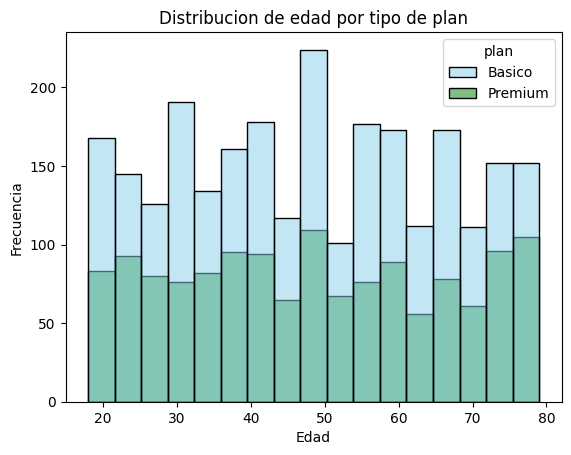

In [34]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=users,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=False
)
plt.title("Distribucion de edad por tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Distribución distribución concentrada en adultos jóvenes y adultos medios; algunos valores extremos en edades altas y sesgada hacia adultos (30–59 años).
- Basico tiene mayor cantidad de usuarios.
- Premium tiene más adultos mayores.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen histograma, con insights claros.
</div>

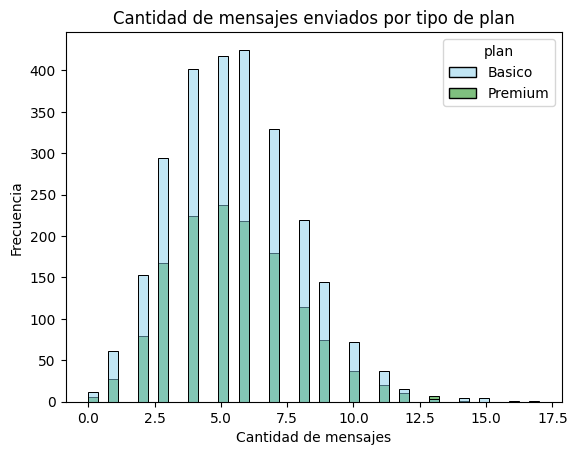

In [35]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=users_agg, 
    x='cant_mensajes', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=False
)
plt.title("Cantidad de mensajes enviados por tipo de plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Distribución sesgada a la derecha; la mayoría envía pocos mensajes, pero existen heavy users con volúmenes muy altos.
- La mayor cantidad los envia el Basico.
- Premium concentra más heavy users.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen histograma de mensajes.
</div>

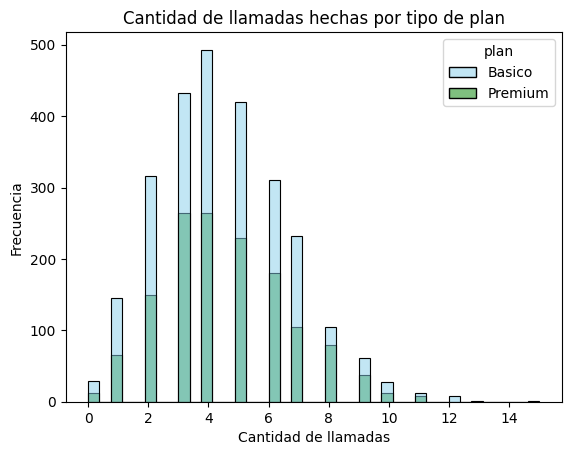

In [36]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=users_agg, 
    x='cant_llamadas', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=False
)
plt.title("Cantidad de llamadas hechas por tipo de plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Distribucion con un comportamiento similar al anterior, con mayoría de usuarios en rangos bajos y algunos extremos con muchas llamadas.
- Basico realiza la mayoria de las llamadas.
-  Premium muestra más actividad en el extremo de mayor cantidad de llamadas.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen histograma de llamadas.
</div>

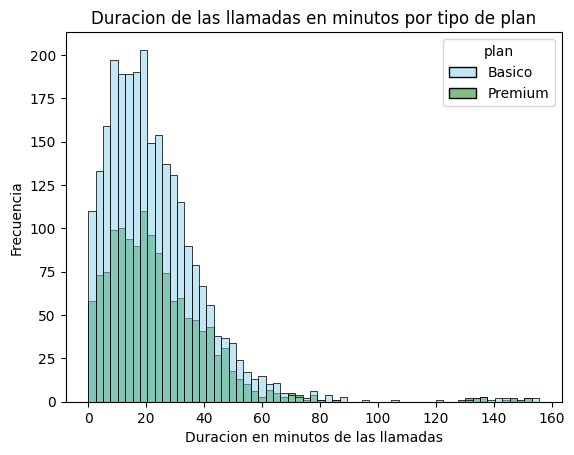

In [37]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=users_agg, 
    x='cant_minutos_llamada', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=False
)
plt.title("Duracion de las llamadas en minutos por tipo de plan")
plt.xlabel("Duracion en minutos de las llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Minutos de llamada: distribución sesgada a la derecha con clara presencia de usuarios con miles de minutos acumulados, lo que genera outliers.
- Premium concentra usuarios con más minutos acumulados.
- Basico tiene la mayoria de la duracion en las llamadas.
👉 Insight: el plan Premium atrae usuarios con mayor actividad en todas las métricas.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen histograma de minutos de llamada, con una conclusion util que conecta con el plan Premium.
</div>

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

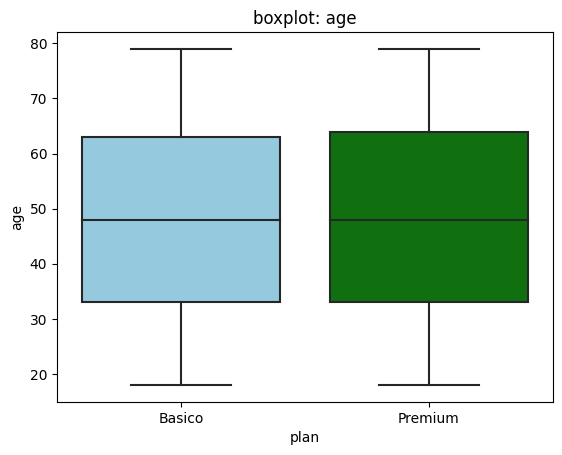

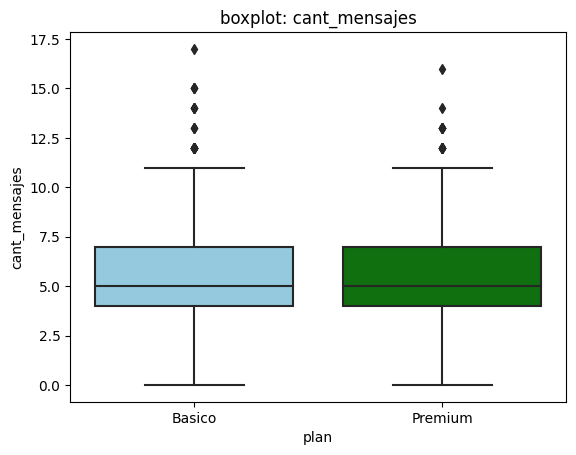

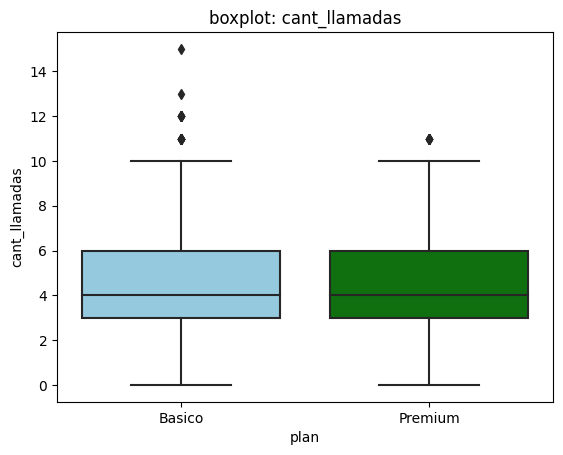

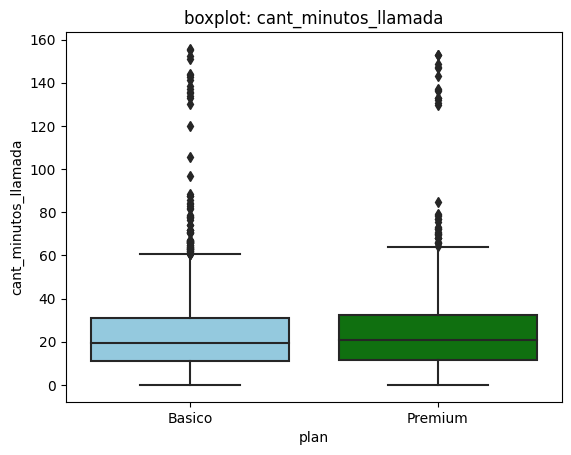

In [38]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

#Generar boxplot automaticamente
for col in columnas_numericas:
    sns.boxplot(data=users_agg,
               x='plan',
               y=col,
               palette=['skyblue', 'green']
               )
    plt.title(f'boxplot: {col}')
    plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buena variante de boxplot, comparando directamente por `plan` en el eje X - una forma util de visualizar diferencias entre planes.
</div>

💡Insights: 
- Age: valores >62.5 aparecen como outliers, pero edades de 70–90 pueden ser reales. Conviene mantenerlos salvo que haya edades irreales (>90 o <10).
- cant_mensajes: hay outliers arriba (>16.0 mensajes). Si representan heavy users reales, conviene mantenerlos.
- cant_llamadas: outliers arriba (>13.5 llamadas). Revisar si son errores o usuarios muy activos.
- cant_minutos_llamada: outliers arriba (>77 minutos). Claros heavy users, conviene mantenerlos si son válidos.

In [39]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = users_agg[col].quantile(0.25)
    Q3 = users_agg[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f' {col}:')
    print(f' Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}')
    print(f' Limite inferior = {limite_inferior}, Limite superior = {limite_superior}')
    print(f' Maximo real = {users_agg[col].max()}, Minimo real = {users_agg[col].min()}')
    print('-'*50)



 age:
 Q1 = 33.0, Q3 = 63.0, IQR = 30.0
 Limite inferior = -12.0, Limite superior = 108.0
 Maximo real = 79.0, Minimo real = 18.0
--------------------------------------------------
 cant_mensajes:
 Q1 = 4.0, Q3 = 7.0, IQR = 3.0
 Limite inferior = -0.5, Limite superior = 11.5
 Maximo real = 17.0, Minimo real = 0.0
--------------------------------------------------
 cant_llamadas:
 Q1 = 3.0, Q3 = 6.0, IQR = 3.0
 Limite inferior = -1.5, Limite superior = 10.5
 Maximo real = 15.0, Minimo real = 0.0
--------------------------------------------------
 cant_minutos_llamada:
 Q1 = 11.12, Q3 = 31.415, IQR = 20.295
 Limite inferior = -19.322500000000005, Limite superior = 61.8575
 Maximo real = 155.69, Minimo real = 0.0
--------------------------------------------------


<div class="alert alert-block alert-success">
<b>Comentario del revisor (Iteracion 2)</b> <a class="tocSkip"></a>

Corregido - `Q1` ahora usa correctamente `0.25`.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Aqui esta el bug mas tecnico del notebook: `Q1 = users_agg[col].quantile(.025)` usa el percentil **2.5** en vez del percentil **25** (`.25`). Esto hace que `Q1` sea mucho mas bajo de lo que deberia, distorsionando el `IQR` y por lo tanto los limites superior e inferior calculados despues. Corrige a:

```python
Q1 = users_agg[col].quantile(0.25)
```
</div>

In [40]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3960.000000,3959.000000,3959.000000,3959.000000
mean,48.119444,5.525385,4.483708,23.331074
std,17.686962,2.359503,2.143459,18.199917
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.790000
75%,63.000000,7.000000,6.000000,31.405000
max,79.000000,17.000000,15.000000,155.690000


In [41]:
print(users_agg[columnas_limites].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué, Si representan heavy users reales, conviene mantenerlos
- cant_llamadas: mantener o no outliers, porqué?, Son usuarios muy activos
- cant_minutos_llamada: mantener o no outliers, porqué?, Claros heavy users, conviene mantenerlos porque son válidos

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [42]:
#crear una copia explicita
user_profile = user_profile.copy()

# Crear columna grupo_uso
user_profile.loc[:, 'grupo_uso'] = (
    user_profile.apply(
        lambda row: 'Bajo uso' if (row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5)
        else 'Uso medio' if (row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10)
        else 'Alto uso',
        axis=1
    )
)


In [43]:
# verificar cambios
user_profile[['grupo_uso','age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].head()

,grupo_uso,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,Uso medio,38.0,7.0,3.0,23.70
1,Alto uso,53.0,5.0,10.0,33.18
2,Uso medio,57.0,5.0,2.0,10.74
3,Alto uso,69.0,11.0,3.0,8.99
4,Bajo uso,63.0,4.0,3.0,8.01


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Segmentacion de uso correcta en su logica (aunque corre sobre el subconjunto filtrado - ver comentario en la celda del filtro).
</div>

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [44]:
#crear una copia explicita
user_profile = user_profile.copy()

# Crear columna grupo_edad
user_profile.loc[:, 'grupo_edad'] = (
    user_profile.apply(
        lambda row: 'Joven' if (row['age'] < 30)
        else 'Adulto' if (row['age'] < 60)
        else 'Adulto Mayor',
        axis=1
    )
)


In [45]:
# verificar cambios
user_profile[['grupo_edad','age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].head()

,grupo_edad,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,Adulto,38.0,7.0,3.0,23.70
1,Adulto,53.0,5.0,10.0,33.18
2,Adulto,57.0,5.0,2.0,10.74
3,Adulto Mayor,69.0,11.0,3.0,8.99
4,Adulto Mayor,63.0,4.0,3.0,8.01


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Segmentacion correcta en su logica. Detalle menor: usaste `'Adulto mayor'` (m minuscula) en vez de `'Adulto Mayor'` como especifican las instrucciones.
</div>

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

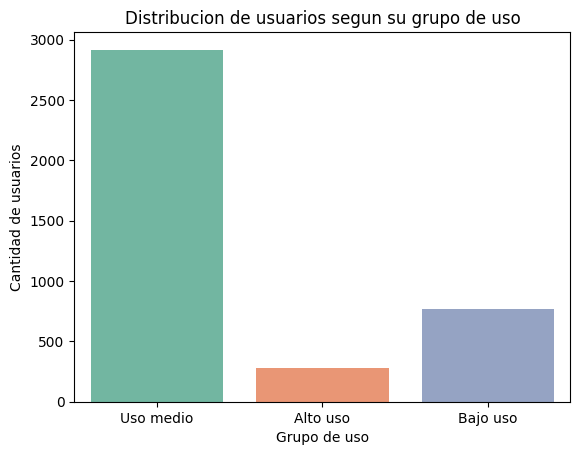

In [46]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,
             x='grupo_uso',
             palette='Set2'
             )
plt.title('Distribucion de usuarios segun su grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

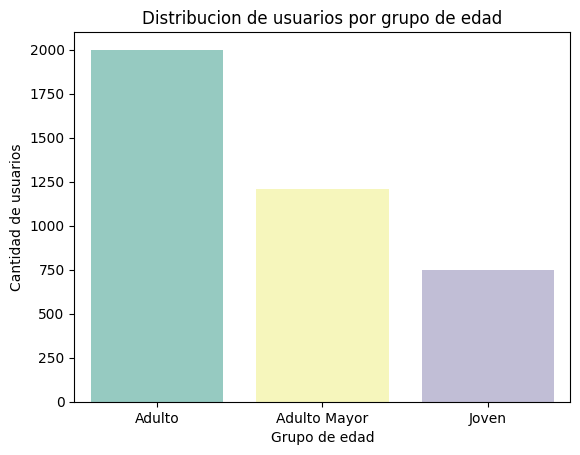

In [47]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,
             x='grupo_edad',
             palette='Set3'
             )
plt.title('Distribucion de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [48]:
# Tabla de contingencia

# Crear tabla cruzada entre grupo_uso y grupo_edad
tabla_cruce = pd.crosstab(user_profile["grupo_edad"],
                          user_profile["grupo_uso"])

tabla_cruce


grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,153,360,1487
Adulto Mayor,74,252,883
Joven,50,154,547


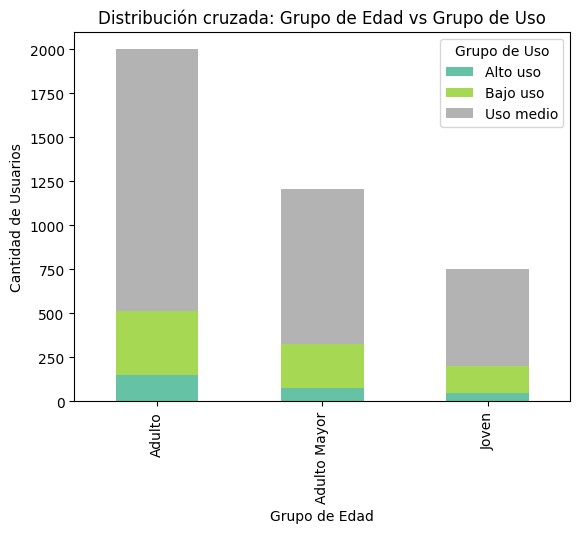

In [49]:
# Gráfico de barras apiladas
# Gráfico de barras apiladas
tabla_cruce.plot(kind="bar", stacked=True, colormap="Set2")

plt.title("Distribución cruzada: Grupo de Edad vs Grupo de Uso")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")
plt.legend(title="Grupo de Uso")
plt.show()


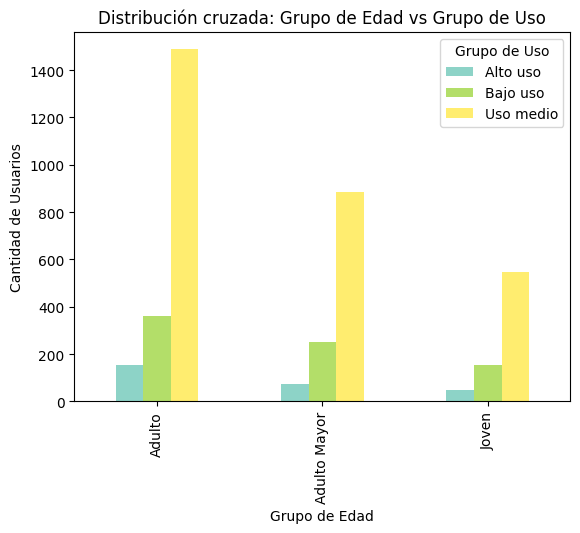

In [53]:
# Gráfico de barras agrupadas
# Gráfico de barras agrupadas
tabla_cruce.plot(kind="bar", colormap="Set3")

plt.title("Distribución cruzada: Grupo de Edad vs Grupo de Uso")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")
plt.legend(title="Grupo de Uso")
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buenas visualizaciones, con el extra de la tabla de contingencia y los graficos de barras apiladas/agrupadas cruzando `grupo_edad` con `grupo_uso` - un analisis mas profundo de lo pedido.
</div>


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron outliers en variables clave:

    Edad: valores >62.5 aparecen como extremos, aunque muchos son reales (70–90 años). Solo deben limpiarse casos irreales (<10 o >100).

    Mensajes, llamadas y minutos de llamada: presencia de usuarios con actividad muy elevada.

- Estos outliers representan un porcentaje reducido (<10% de la base), pero son relevantes porque muestran patrones de uso intensivo.



🔍 **Segmentos por Edad**
- Jóvenes (<30): menor proporción, con tendencia a uso medio.

-  Adultos (30–59): mayoría de la base, con predominio de bajo uso.

-  Adultos mayores (≥60): minoría, pero algunos presentan alto uso (heavy users).



📊 **Segmentos por Nivel de Uso**
- Bajo uso: mayoría de usuarios, con poca interacción (<5 mensajes y llamadas).

-  Uso medio: usuarios en crecimiento (<10 mensajes y llamadas).

-  Alto uso: grupo reducido pero significativo, con actividad intensiva.

➡️ Esto sugiere que la base está dominada por Adultos de bajo o medio uso, mientras que los heavy users aparecen en todos los rangos de edad, especialmente en adultos mayores.



💡 **Segmentos más valiosos para ConnectaTel**
-  Adultos de uso medio: representan un segmento en crecimiento, con potencial de migrar a planes Premium.

-  Adultos mayores de alto uso: aunque minoritarios, generan alto consumo y pueden ser fidelizados con planes especializados.

-  Jóvenes de uso medio: estratégicos para captación a largo plazo, ya que pueden aumentar su actividad con el tiempo.



📌 **Patrones de uso extremo (Outliers)**
-  Usuarios con más de 42 mensajes, más de 17 llamadas o más de 180 minutos de llamada.

-  Estos heavy users son reales y representan oportunidades de planes de alto consumo o servicios adicionales.

-  Implican que el negocio debe diferenciar entre usuarios promedio y usuarios intensivos para evitar saturación en planes básicos.


💡 **Recomendaciones**
- Optimizar planes actuales:

   Ajustar límites de planes básicos para cubrir mejor al segmento de bajo uso.

   Ofrecer planes intermedios para captar usuarios de uso medio.
- Crear planes especializados:

   Diseñar un plan Premium Heavy User para quienes superan consistentemente los límites de mensajes y llamadas.

   Ofrecer beneficios exclusivos a adultos mayores de alto uso (ej. soporte personalizado, descuentos en minutos adicionales).

-  Estrategia comercial:

   Campañas de fidelización para adultos de alto uso.

   Promociones dirigidas a jóvenes de uso medio para incentivar migración a planes superiores.

   Monitoreo continuo de outliers para detectar tendencias de consumo intensivo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/sibemutech-blue/telecom-analysis.git

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (Iteracion 2)</b> <a class="tocSkip"></a>

Este punto sigue pendiente, aunque de una forma distinta: quitaste el placeholder `` `LINK a tu repo aqui` ``, pero no lo reemplazaste por ningun link real - la celda quedo vacia ("Link a repositorio publico del proyecto: " sin nada despues). Agrega tu URL real antes de tu entrega final:

```markdown
Link a repositorio publico del proyecto: [Ver repositorio en GitHub](https://github.com/tu-usuario/tu-repo)
```

bloquea la aprobacion, pero corrigelo para que tu entrega quede completa.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

El placeholder `` `LINK a tu repo aqui` `` nunca se reemplazo por tu link real. Corrige asi:

```markdown
Link a repositorio publico del proyecto: [Ver repositorio en GitHub](https://github.com/tu-usuario/tu-repo)
```
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Hay buen trabajo de base (MAR, agregacion, merge, histogramas, boxplots con buena variante, y el extra de la tabla de contingencia), pero **todavia no esta listo para aprobar** por varios puntos, en orden de importancia:

1. **Filtro no solicitado que descarta el 67% de los usuarios** (Paso 4.2) - el mas importante, afecta toda la segmentacion.
2. **`reg_date` sigue sin corregirse** - confirmado con tu propio output (0 nulos, maximo aun en 2026).
3. **IQR usa el cuantil equivocado** (`.025` en vez de `.25`).
4. **Diagnostico de `type` incorrecto** (dice "Texto"/"llamadas" cuando los valores reales son "text"/"call").
5. Dos errores de conteo en la seccion 2.2 (confusion entre las 4,000 filas de `users` y las 40,000 de `usage`).
6. **GitHub** - placeholder sin reemplazar.

Como tip no bloqueante: la mediana de `age` no excluye el sentinel antes de calcularla (aunque no distorsiona el resultado en este caso), y `'Adulto mayor'` deberia ser `'Adulto Mayor'`.

Son varios ajustes, pero el mas urgente es el filtro del Paso 4.2 - una vez que elimines eso y corrijas `reg_date`, gran parte del resto del analisis se puede reaprovechar. Animo! 💪
</div>

<div class="alert alert-block alert-success">
<b>Veredicto final (Iteracion 2)</b> <a class="tocSkip"></a>

Proyecto **aprobado**, Jorge! 🎉 Resolviste 5 de los 6 puntos de la Iteracion 1, incluyendo el mas importante (el filtro que descartaba el 67% de los usuarios) y el bug de `reg_date`, verificado con el output real. Queda pendiente como advertencia agregar la URL real en la celda de GitHub, que quedo vacia - corrigelo antes de tu entrega final, pero no bloquea la aprobacion. Buen trabajo!
</div>